### Build a basic Chatbot with langGraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
from langchain_core.output_parsers import list
class State(TypedDict):
    messages : Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()




True

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "qwen/qwen3-32b")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CA6E8DF8C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CA6EB00440>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

#Adding nodes
graph_builder.add_node("llmchatbot", chatbot)

#Adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot",END)

# Compile the graph
graph = graph_builder.compile()

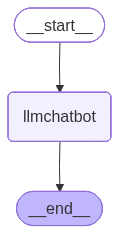

In [9]:
#Visualize the grpah
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages":"Hi"})
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='fd75af38-663d-4a64-92f6-7a1e162e69d0'),
 AIMessage(content='<think>\nOkay, the user said "Hi". I should respond in a friendly and welcoming way. Maybe ask how I can assist them. Keep it open-ended so they can tell me what they need help with. Let me make sure the tone is positive and helpful.\n</think>\n\nHello! How can I assist you today? Feel free to ask me anything or let me know if you need help with a specific task. 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 9, 'total_tokens': 96, 'completion_time': 0.175295952, 'completion_tokens_details': None, 'prompt_time': 0.000420104, 'prompt_tokens_details': None, 'queue_time': 0.051617515, 'total_time': 0.175716056}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f5581-1

In [11]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1])


content='<think>\nOkay, the user asked "Hi How are you?" I need to respond appropriately. First, I should acknowledge their greeting. Since I\'m an AI, I don\'t have feelings, but I can express that I\'m functioning well. At the same time, I need to show enthusiasm and willingness to help, encouraging them to ask questions. The tone should be friendly and approachable, avoiding any robotic or formal language. I should keep it concise and natural, making sure they feel comfortable to engage further. Let me put that together in a warm and inviting way.\n</think>\n\nHello! I\'m functioning well, thank you for asking! I\'m here to help, so if you have any questions or need assistance, feel free to ask. How can I support you today? 😊' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 160, 'prompt_tokens': 13, 'total_tokens': 173, 'completion_time': 0.323851423, 'completion_tokens_details': None, 'prompt_time': 0.000392654, 'prompt_tokens_details': None, 'queue_tim

In [12]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [13]:
## Custom functions
def multiply(a:int, b:int)->int:
    """Multiply a and b

    Args :
        a(int): first int
        b(int): second int
    
    Returns:
        int: output int""" 

    return a*b
        

In [14]:
tools = [tool,multiply]

In [15]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CA6E8DF8C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CA6EB00440>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for com

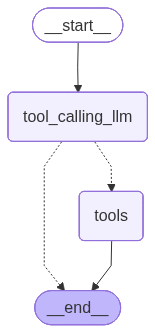

In [16]:
### StateGraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)

builder.add_edge("tools",END)

##Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
response=graph.invoke({"messages":"What is the recent AI news"})
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": ["https://i.ytimg.com/vi/p06A_fkM3nY/hq720.jpg?sqp=-oaymwEhCK4FEIIDSFryq4qpAxMIARUAAAAAGAElAADIQj0AgKJD&rs=AOn4CLDlT9JAUp1e99P_HgYGdZXbb1xqew", "https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3935475504551356845", "https://assets.st-note.com/production/uploads/images/293037697/rectangle_large_type_2_b158b4359bee43c0f2e7963496a814dd.png", "https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3935844693166312164", "https://shiftscore.today/wp-content/uploads/2026/07/Untitled-design-87.png"], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.7923522, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "The last three days have been a nonstop parade of new products, features, and frontier model releases from the leadi

In [18]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (qnxx01kfd)
 Call ID: qnxx01kfd
  Args:
    include_images: True
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": ["https://i.ytimg.com/vi/p06A_fkM3nY/hq720.jpg?sqp=-oaymwEhCK4FEIIDSFryq4qpAxMIARUAAAAAGAElAADIQj0AgKJD&rs=AOn4CLDlT9JAUp1e99P_HgYGdZXbb1xqew", "https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3935475504551356845", "https://assets.st-note.com/production/uploads/images/293037697/rectangle_large_type_2_b158b4359bee43c0f2e7963496a814dd.png", "https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=393584469316

In [19]:
response = graph.invoke({"messages":"What is 2 multiplied by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (dzcj4cdhc)
 Call ID: dzcj4cdhc
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [20]:
response = graph.invoke({"messages":"What is 2 multiplied by 3 anfd then multiply by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3 anfd then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (e8hd7125k)
 Call ID: e8hd7125k
  Args:
    a: 2
    b: 3
  multiply (ts8y8a270)
 Call ID: ts8y8a270
  Args:
    a: 6
    b: 10
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: multiply

60


In [21]:
response = graph.invoke({"messages":"Give me the recent ai news and then do 5 multiply by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then do 5 multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (wwh374efb)
 Call ID: wwh374efb
  Args:
    query: AI news
    time_range: week
  multiply (rrd2whf0k)
 Call ID: rrd2whf0k
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=EOCRtSnvNNE", "title": "AI News: GPT-5.6 and the new Super App are a Massive Leap!", "content": "AI News: GPT-5.6 and the new Super App are a Massive Leap!\nMatt Wolfe\n977000 subscribers\n2216 likes\n53389 views\n10 Jul 2026\nHere's the AI News You Might Have Missed This Week. Try my Shorts Broll Generator and get $1,000 in free credits for Hyperagent here: https:/

### Adding Memory in Agentic Graph

In [22]:
response = graph.invoke({"messages":"Hello My name is Anshumaan"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello My name is Anshumaan
================================== Ai Message ==================================

Hello Anshumaan! How can I assist you today?


In [23]:
response = graph.invoke({"messages":"What is my name?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

The assistant doesn't have access to your personal information, including your name. If you'd like to use any of the available tools (search engine or calculator), you can provide your name in your next message if desired.


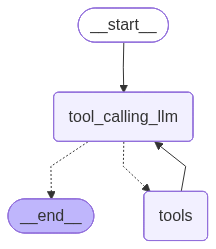

In [24]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)

builder.add_edge("tools","tool_calling_llm")

##Compile the graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
config = {"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":"My name is Anshumaan"},config=config)
response

{'messages': [HumanMessage(content='My name is Anshumaan', additional_kwargs={}, response_metadata={}, id='ce2deee5-e734-4634-a9f4-7ad70b0ff73e'),
  AIMessage(content='Hello, Anshumaan! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "My name is Anshumaan." Let me think about how to respond.\n\nFirst, I need to acknowledge their name. A simple "Hello, Anshumaan!" would be friendly. Then, maybe offer assistance. They might need help with something, so I should ask how I can assist them today. Let me check if there\'s any other info needed. The tools provided include a search function and a multiply function, but the user hasn\'t asked for anything specific yet. So, the best move is to greet them and offer help. Keep it open-ended. No need to call any functions here since there\'s no explicit request. Just a standard welcoming response.\n'}, response_metadata={'token_usage': {'completion_tokens': 161, 'prompt_tokens': 1790, 'total_tokens': 1951

In [26]:
response = graph.invoke({"messages":"What is my name?"},config=config)
response['messages'][-1].content

'Your name is Anshumaan.'

### Streaming

In [27]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [28]:
def superbot(state:State):
    return {"messsages":[llm.invoke(state['messages'])]}

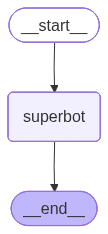

In [29]:
graph = StateGraph(State)

# Node
graph.add_node("superbot",superbot)

#Edges
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder=graph.compile(checkpointer=memory)

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [30]:
# Invokation

config = {"configurable": {"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi my name is Anshumaan and I like football"},config)

{'messages': 'Hi my name is Anshumaan and I like football'}

# Streaming

Methods: `.stream()` and `.astream()`

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values**: This streams the full state of the graph after each node is called.
- **updates**: This streams updates to the state of the graph after each node is called.

In [31]:
# create a thread
config = {"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':"Hi, my names is Anshumaan and I like football"},config,stream_mode="updates"):
    print(chunk)

{'superbot': None}


In [32]:
# create a thread
config = {"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':"Hi, my names is Anshumaan and I like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my names is Anshumaan and I like football', additional_kwargs={}, response_metadata={}, id='346168f8-bcc3-47ce-82a6-b85c1e2dce6d'), HumanMessage(content='Hi, my names is Anshumaan and I like football', additional_kwargs={}, response_metadata={}, id='e6cb35c4-8cd5-4a93-991c-139b98accc06')]}


In [33]:
# create a thread
config = {"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':"Hi, my names is Anshumaan and I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my names is Anshumaan and I like football', additional_kwargs={}, response_metadata={}, id='346168f8-bcc3-47ce-82a6-b85c1e2dce6d'), HumanMessage(content='Hi, my names is Anshumaan and I like football', additional_kwargs={}, response_metadata={}, id='e6cb35c4-8cd5-4a93-991c-139b98accc06'), HumanMessage(content='Hi, my names is Anshumaan and I like cricket', additional_kwargs={}, response_metadata={}, id='113c2b51-0c26-475c-95de-776230249f67')]}


In [34]:
# create a thread
config = {"configurable": {"thread_id":"5"}}

async for event in graph_builder.astream_events({'messages':["Hi, my names is Anshumaan and I like cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, my names is Anshumaan and I like cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f5582-f387-75a0-a9f3-cab80a0542e0', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, my names is Anshumaan and I like cricket']}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019f5582-f38a-79e1-9000-6a3a7309c0ad', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:368112dc-e79f-4763-bc70-eadd820939ec'}, 'parent_ids': ['019f5582-f387-75a0-a9f3-cab80a0542e0']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi, my names is Anshumaan and I like cricket', additional_kwargs={}, response_metadata={

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `qwen/qwen3-32b` in organization `org_01kjr60x99f8yae1kh761bd632` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5386, Requested 707. Please try again in 929.999999ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

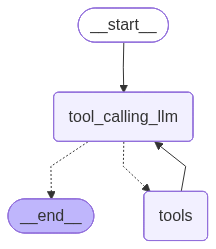

In [47]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, Interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query : str) -> str:
    """ Request assistance from a human """
    human_response = Interrupt({"query":query})
    return human_response["data"]

tool = TavilySearch(max_results = 2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state : State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges("chatbot",tools_condition)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [42]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1]

In [50]:

human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1]

KeyError: 'messages'